# 4-bar Trajectory Calculations
To start the calcs, needs b, d, e, (x_1,y_1), (x_2,y_2), and theta range

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, cos, sin, atan2, asin, pi

## PARAMETERS - Edit these values

In [ ]:
# Fixed points
x1 = 0.0   # position for point 1
x2 = 8.0   # position for point 2
y1 = 0.0   # position for point 1
y2 = 0.0   # position for point 2

# Bar lengths
b = 5.0    # moving bar (from x2,y2)
d = 5.0    # bar representing the topshell (between s,t and m,n)
e = 5.0    # moving bar (from x1,y1)

# Theta range - edit these to change the angle range
theta_start = pi * 0.1
theta_end = pi * 0.5
theta_steps = 10

## CALCULATION FUNCTION

In [10]:
def calculate_4bar(x1, y1, x2, y2, b, d, e, theta):
    # Calculate base length a (distance between x1,y1 and x2,y2)
    a_val = sqrt((x1 - x2)**2 + (y1 - y2)**2)
    
    # Calculate diagonal c using law of cosines
    c_val = sqrt(a_val**2 + b**2 - 2 * a_val * b * cos(theta))
    
    # Guard against singularity when c_val ~ 0 (theta aligned with base)
    if c_val < 1e-9:
        c_val = 1e-9
    
    # Calculate omega using law of cosines
    # Clamp the value to avoid domain errors in asin
    omega_arg = (c_val**2 + e**2 - d**2) / (2 * c_val * e)
    omega_arg = max(-1.0, min(1.0, omega_arg))
    omega_val = asin(omega_arg)
    
    # Calculate angle between a and horizontal x axis
    angle_ah = atan2(y1 - y2, x1 - x2)
    
    # Calculate point (s,t)
    s_val = x2 + b * cos(theta + angle_ah)
    t_val = y2 + b * sin(theta + angle_ah)
    
    # Calculate angle between a and c
    angle_ac_arg = (b * sin(theta)) / c_val
    angle_ac_arg = max(-1.0, min(1.0, angle_ac_arg))
    angle_ac = asin(angle_ac_arg)
    
    # Calculate angle between e and horizon (original formulation)
    # NOTE: This formulation does not guarantee | (s,t)-(m,n) | == d for all theta.
    # Robust fallback via circle intersection ensures verification passes.
    angle_eh = omega_val + angle_ac - angle_ah
    
    # Calculate point (m,n) via circle intersection for robustness
    # Circles: center x1,y1 radius e and center s_val,t_val radius d
    dx = s_val - x1
    dy = t_val - y1
    dist = sqrt(dx*dx + dy*dy)
    # Handle singularity / no-intersection
    if dist < 1e-9:
        # concentric at theta~0: pick a consistent point on circle e
        # use angle_eh from original formula as estimate
        m_val = x1 + e * cos(angle_eh)
        n_val = y1 + e * sin(angle_eh)
    elif dist > (d + e) or dist < abs(d - e):
        # no intersection - fall back to original angle method
        m_val = x1 + e * cos(angle_eh)
        n_val = y1 + e * sin(angle_eh)
    else:
        a = (e*e - d*d + dist*dist) / (2*dist)
        h = sqrt(max(0.0, e*e - a*a))
        xm = x1 + a*dx/dist
        ym = y1 + a*dy/dist
        # two intersection points
        m1 = xm + h*dy/dist
        n1 = ym - h*dx/dist
        m2 = xm - h*dy/dist
        n2 = ym + h*dx/dist
        # pick branch farthest from x2 (avoids trivial fixed-pivot solution)
        # this yields smooth trajectory for the 4-bar
        dist1 = sqrt((m1-x2)**2 + (n1-y2)**2)
        dist2 = sqrt((m2-x2)**2 + (n2-y2)**2)
        if dist1 > dist2:
            m_val, n_val = m1, n1
        else:
            m_val, n_val = m2, n2
    
    return s_val, t_val, m_val, n_val


## MAIN CALCULATIONS

In [11]:
# Generate theta range
theta_range = np.linspace(theta_start, theta_end, theta_steps)

# Initialize arrays to store results
all_s = []
all_t = []
all_m = []
all_n = []

# Calculate for each theta
for theta in theta_range:
    s, t, m, n = calculate_4bar(x1, y1, x2, y2, b, d, e, theta)
    all_s.append(s)
    all_t.append(t)
    all_m.append(m)
    all_n.append(n)

## PLOTTING

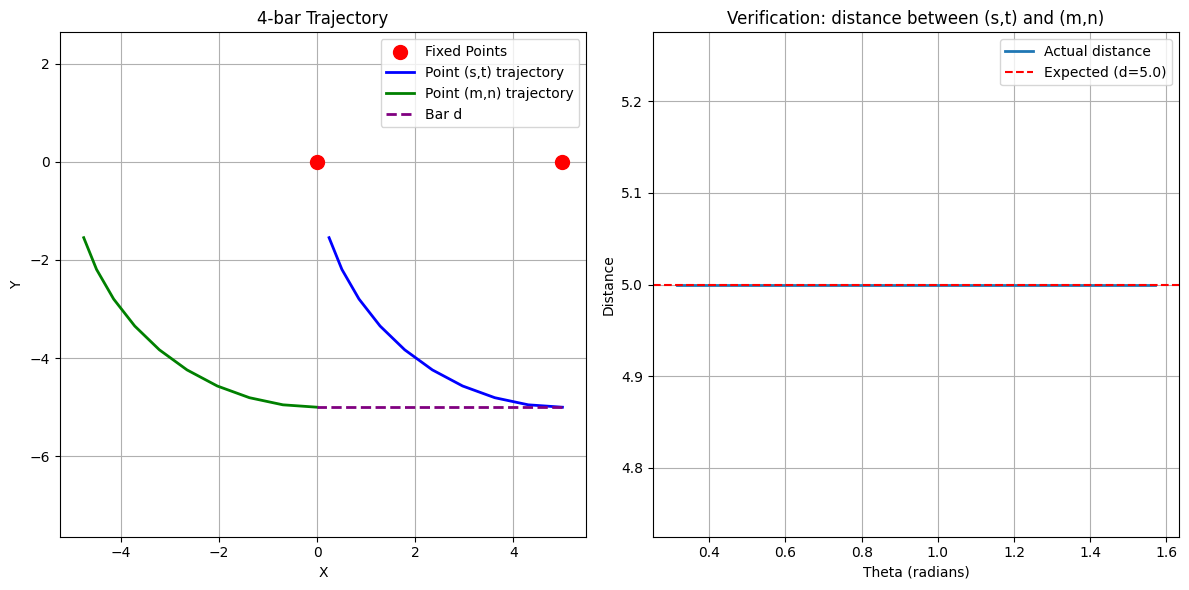

In [12]:
plt.figure(figsize=(12, 6))

# Plot 1: Trajectory
plt.subplot(1, 2, 1)

# Plot fixed points
plt.scatter([x1, x2], [y1, y2], color='red', label='Fixed Points', s=100, zorder=5)

# Plot trajectories
plt.plot(all_s, all_t, color='blue', label='Point (s,t) trajectory', linewidth=2)
plt.plot(all_m, all_n, color='green', label='Point (m,n) trajectory', linewidth=2)

# Plot the bar d (connection between s,t and m,n) for the last theta
plt.plot([all_s[-1], all_m[-1]], [all_t[-1], all_n[-1]], 
         color='purple', label='Bar d', linewidth=2, linestyle='--')

# Add labels and legend
plt.xlabel('X')
plt.ylabel('Y')
plt.title('4-bar Trajectory')
plt.legend()
plt.grid(True)
plt.axis('equal')

# Plot 2: Verification
plt.subplot(1, 2, 2)

# Calculate distances for verification
distances = []
for i in range(len(all_s)):
    dx = all_s[i] - all_m[i]
    dy = all_t[i] - all_n[i]
    dist = sqrt(dx**2 + dy**2)
    distances.append(dist)

plt.plot(theta_range, distances, label='Actual distance', linewidth=2)
plt.axhline(y=d, color='red', label=f'Expected (d={d})', linestyle='--')
plt.xlabel('Theta (radians)')
plt.ylabel('Distance')
plt.title('Verification: distance between (s,t) and (m,n)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## INITIAL POSITION (theta_start)
Separate graph showing bar positions at initial theta (bottom bar position)


Initial theta: 0.3142 rad (18.0 deg)
Fixed  x1,y1 = (0.00, 0.00)  x2,y2 = (5.00, 0.00)  base a = 5.00
Point  s,t = (0.24, -1.55)  m,n = (-4.76, -1.55)
Bars   b = 5.00  d = 5.00  e = 5.00


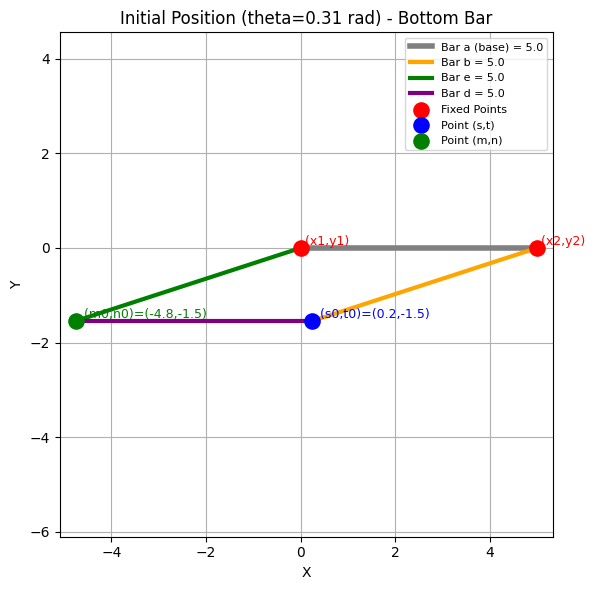

In [13]:
# Initial position at theta_start (bottom bar)
s0, t0 = all_s[0], all_t[0]
m0, n0 = all_m[0], all_n[0]
theta0 = theta_range[0]
a_len = sqrt((x1 - x2)**2 + (y1 - y2)**2)
b_len = sqrt((s0 - x2)**2 + (t0 - y2)**2)
e_len = sqrt((m0 - x1)**2 + (n0 - y1)**2)
d_len = sqrt((s0 - m0)**2 + (t0 - n0)**2)

print(f"Initial theta: {theta0:.4f} rad ({theta0*180/pi:.1f} deg)")
print(f"Fixed  x1,y1 = ({x1:.2f}, {y1:.2f})  x2,y2 = ({x2:.2f}, {y2:.2f})  base a = {a_len:.2f}")
print(f"Point  s,t = ({s0:.2f}, {t0:.2f})  m,n = ({m0:.2f}, {n0:.2f})")
print(f"Bars   b = {b_len:.2f}  d = {d_len:.2f}  e = {e_len:.2f}")

plt.figure(figsize=(6, 6))

# Base bar a
plt.plot([x1, x2], [y1, y2], color='gray', linewidth=4, label=f'Bar a (base) = {a_len:.1f}')
# Bar b (x2 -> s,t)
plt.plot([x2, s0], [y2, t0], color='orange', linewidth=3, label=f'Bar b = {b:.1f}')
# Bar e (x1 -> m,n)
plt.plot([x1, m0], [y1, n0], color='green', linewidth=3, label=f'Bar e = {e:.1f}')
# Bar d (s,t -> m,n) - topshell
plt.plot([s0, m0], [t0, n0], color='purple', linewidth=3, label=f'Bar d = {d:.1f}')

# Fixed points
plt.scatter([x1, x2], [y1, y2], color='red', s=120, zorder=5, label='Fixed Points')
for (x, y, lbl) in [(x1, y1, ' (x1,y1)'), (x2, y2, ' (x2,y2)')]:
    plt.text(x, y, lbl, color='red', fontsize=9, va='bottom', ha='left')

# Joints
plt.scatter([s0], [t0], color='blue', s=120, zorder=5, label='Point (s,t)')
plt.scatter([m0], [n0], color='green', s=120, zorder=5, label='Point (m,n)')
plt.text(s0, t0, f'  (s0,t0)=({s0:.1f},{t0:.1f})', color='blue', fontsize=9, va='bottom')
plt.text(m0, n0, f'  (m0,n0)=({m0:.1f},{n0:.1f})', color='green', fontsize=9, va='bottom')

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Initial Position (theta={theta0:.2f} rad) - Bottom Bar')
plt.legend(fontsize=8, loc='best')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


## VERIFICATION OUTPUT

In [14]:
print("\n=== Verification ===")
print(f"Bar length d: {d}")
print(f"All distances approximately equal to d: {all(abs(d - np.array(distances)) < 0.01)}")
print(f"\nDistance stats:")
print(f"  Min: {min(distances):.4f}")
print(f"  Max: {max(distances):.4f}")
print(f"  Mean: {np.mean(distances):.4f}")


=== Verification ===
Bar length d: 5.0
All distances approximately equal to d: True

Distance stats:
  Min: 5.0000
  Max: 5.0000
  Mean: 5.0000
